In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi Spark LENGKAP
spark = SparkSession.builder \
    .appName("ML_Turnover_Static") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://bda-minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("✅ Spark Session berhasil diinisialisasi!")

✅ Spark Session berhasil diinisialisasi!


In [2]:
# 2. Tarik Data Gold dari MinIO
minio_gold_path = "s3a://datalake/gold/employee-attrition/"
print(f"📥 Membaca data Parquet dari: {minio_gold_path}...")
gold_df = spark.read.parquet(minio_gold_path)

# 3. Split Data
train_split, test_split = gold_df.randomSplit([0.8, 0.2], seed=42)

print(f"   - Data Training : {train_split.count():,} baris")
print(f"   - Data Testing  : {test_split.count():,} baris")
print("✅ Data berhasil ditarik dan di-split!")

📥 Membaca data Parquet dari: s3a://datalake/gold/employee-attrition/...
   - Data Training : 47,836 baris
   - Data Testing  : 11,762 baris
✅ Data berhasil ditarik dan di-split!


In [3]:
# 4. Setup Model STATIS (Langsung tentukan angka mutlak)
rf_static = RandomForestClassifier(
    labelCol="label", 
    featuresCol="features", 
    numTrees=100, 
    maxDepth=10, 
    seed=42
)

# Evaluator untuk metrik pengukuran
mc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
roc_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

print("✅ Model Random Forest Statis dan Evaluator siap digunakan.")

✅ Model Random Forest Statis dan Evaluator siap digunakan.


In [4]:
# 5. Fit & Prediksi (TANPA Cross Validation, langsung dilatih ke data)
print("⏳ Sedang melatih model statis (numTrees=100, maxDepth=10)...")

static_model = rf_static.fit(train_split)
predictions = static_model.transform(test_split)

print("✅ Pelatihan selesai dan prediksi berhasil dilakukan!")

⏳ Sedang melatih model statis (numTrees=100, maxDepth=10)...
✅ Pelatihan selesai dan prediksi berhasil dilakukan!


In [5]:
# 6. Tarik Metrik Evaluasi
accuracy = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "accuracy"})
f1 = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "f1"})
auc_roc = roc_evaluator.evaluate(predictions) 

print("--- 📊 HASIL EVALUASI MODEL STATIS ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")

--- 📊 HASIL EVALUASI MODEL STATIS ---
Accuracy  : 0.7432
F1 Score  : 0.7431
AUC-ROC   : 0.8287


In [6]:
# 7. Ekstrak Feature Importance dari Model Statis
importance = static_model.featureImportances.toArray()

try:
    # Tarik nama-nama fitur dari metadata kolom 'features'
    attrs = gold_df.schema["features"].metadata["ml_attr"]["attrs"]
    list_attrs = attrs.get("numeric", []) + attrs.get("binary", []) + attrs.get("nominal", [])
    feature_names = [x["name"] for x in sorted(list_attrs, key=lambda x: x["idx"])]
    
    # Gabungkan nama fitur dan skor kepentingannya ke dalam Pandas DataFrame
    importance_df = pd.DataFrame(
        list(zip(feature_names, importance)), 
        columns=["Feature", "Importance"]
    ).sort_values(by="Importance", ascending=False)

    print("--- 🏆 TOP 10 FEATURE IMPORTANCE (MODEL STATIS) ---")
    print(importance_df.head(10))

except Exception as e:
    print(f"⚠️ Error saat menarik nama kolom: {e}")

--- 🏆 TOP 10 FEATURE IMPORTANCE (MODEL STATIS) ---
                       Feature  Importance
34   Marital Status_ohe_Single    0.146727
38        Job Level_ohe_Senior    0.136761
36         Job Level_ohe_Entry    0.112662
42          Remote Work_ohe_No    0.075943
43         Remote Work_ohe_Yes    0.068194
33  Marital Status_ohe_Married    0.062449
37           Job Level_ohe_Mid    0.034430
3         Number of Promotions    0.031073
15  Work-Life Balance_ohe_Fair    0.030220
4           Distance from Home    0.029181


/tmp/ipykernel_7330/829430981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


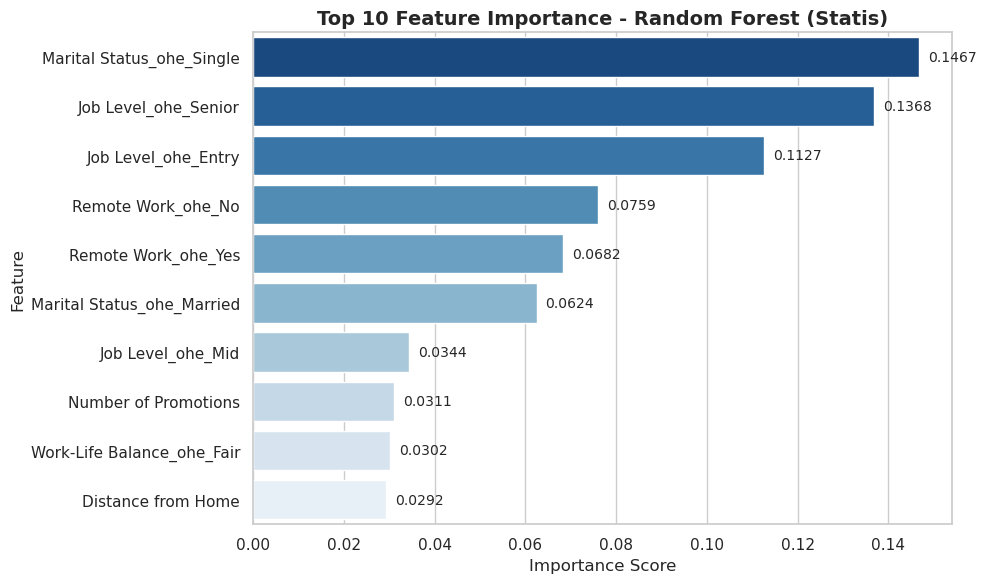

In [7]:
# 8. Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Buat barplot
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=importance_df.head(10), 
    palette="Blues_r"
)

plt.title("Top 10 Feature Importance - Random Forest (Statis)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Tambahkan angka skor persis di ujung tiap batang
for index, value in enumerate(importance_df.head(10)["Importance"]):
    plt.text(value + 0.002, index, f'{value:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()